<a href="https://colab.research.google.com/github/saiDan77/nn-from-scratch/blob/main/1M_Text.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

RAW DATA
Characters: 1115394

First 500 characters:

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor

BYTE TOKENIZATION
Number of bytes: 1115394

First 50 bytes:
[70, 105, 114, 115, 116, 32, 67, 105, 116, 105, 122, 101, 110, 58, 10, 66, 101, 102, 111, 114, 101, 32, 119, 101, 32, 112, 114, 111, 99, 101, 101, 100, 32, 97, 110, 121, 32, 102, 117, 114, 116, 104, 101, 114, 44, 32, 104, 101, 97, 114]

Tensor shape: torch.Size([1115394])
Tensor dtype: torch.int64

First 50 token IDs:
[70, 105, 114, 115, 116, 32, 67, 105, 116, 105, 122, 101, 110, 58

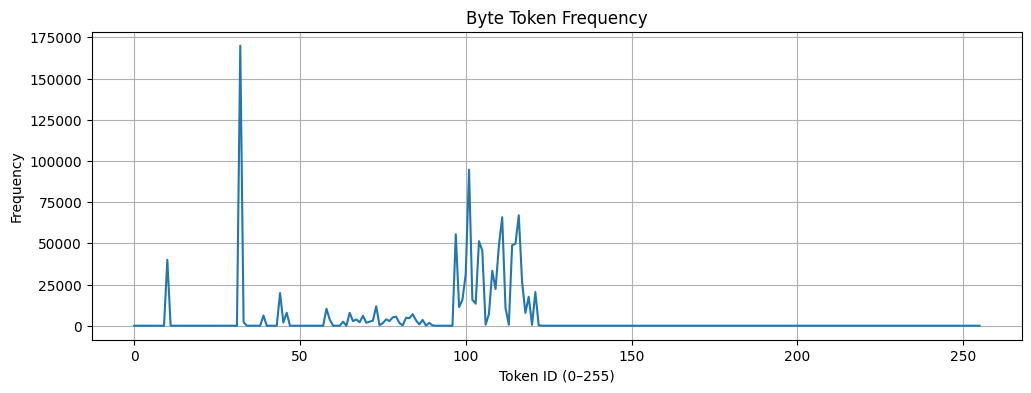


PIPELINE SUMMARY

RAW TEXT
   ↓
UTF-8 ENCODING
   ↓
BYTES
   ↓
TOKEN IDs 0...255
   ↓
TRAIN / VALIDATION SPLIT
   ↓
RANDOM SEQUENCE SAMPLING
   ↓
X = [B, T]
Y = [B, T]
   ↓
LANGUAGE MODEL
   ↓
LOGITS = [B, T, V]
   ↓
CROSS ENTROPY


Vocabulary: 256
Context: 128
Batch: 16

X shape:
torch.Size([16, 128])

Y shape:
torch.Size([16, 128])

Ready to connect this directly to the Transformer.


In [1]:
# ============================================================
# REAL TEXT DATA PIPELINE — FROM SCRATCH
# BYTE-LEVEL TOKENIZER
# ============================================================

import torch
import requests
import matplotlib.pyplot as plt

# ============================================================
# 1. DOWNLOAD A SMALL REAL TEXT CORPUS
# ============================================================

url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"

text = requests.get(url).text

print("=" * 70)
print("RAW DATA")
print("=" * 70)

print("Characters:", len(text))

print()
print("First 500 characters:")
print()
print(text[:500])


# ============================================================
# 2. BYTE-LEVEL TOKENIZER
# ============================================================

# Every UTF-8 byte has a value from 0 to 255.
#
# Therefore:
#
# vocabulary size = 256
#
# This is extremely simple:
#
# text
#   ↓
# UTF-8
#   ↓
# bytes
#   ↓
# integers 0...255

encoded = text.encode("utf-8")

print()
print("=" * 70)
print("BYTE TOKENIZATION")
print("=" * 70)

print("Number of bytes:", len(encoded))

print()
print("First 50 bytes:")
print(list(encoded[:50]))


# ============================================================
# 3. BYTES → PYTORCH TENSOR
# ============================================================

data = torch.tensor(
    list(encoded),
    dtype=torch.long
)

print()
print("Tensor shape:", data.shape)

print("Tensor dtype:", data.dtype)

print()
print("First 50 token IDs:")
print(data[:50].tolist())


# ============================================================
# 4. VOCABULARY
# ============================================================

VOCAB_SIZE = 256

print()
print("=" * 70)
print("VOCABULARY")
print("=" * 70)

print("Vocabulary size:", VOCAB_SIZE)

print(
    "Minimum token ID:",
    data.min().item()
)

print(
    "Maximum token ID:",
    data.max().item()
)


# ============================================================
# 5. BYTE → CHARACTER HELPER
# ============================================================

def decode(tokens):

    # tokens can be a tensor or list

    if isinstance(tokens, torch.Tensor):

        tokens = tokens.tolist()

    return bytes(tokens).decode(
        "utf-8",
        errors="replace"
    )


def encode(text):

    return torch.tensor(
        list(
            text.encode("utf-8")
        ),
        dtype=torch.long
    )


# Test tokenizer

sample = "Hello world!"

tokens = encode(sample)

print()
print("=" * 70)
print("TOKENIZER TEST")
print("=" * 70)

print("Text:")
print(sample)

print()
print("Token IDs:")
print(tokens.tolist())

print()
print("Decoded:")
print(decode(tokens))


# ============================================================
# 6. TRAIN / VALIDATION SPLIT
# ============================================================

split = int(
    len(data) * 0.90
)

train_data = data[:split]

val_data = data[split:]

print()
print("=" * 70)
print("DATA SPLIT")
print("=" * 70)

print(
    "Total tokens:",
    len(data)
)

print(
    "Training tokens:",
    len(train_data)
)

print(
    "Validation tokens:",
    len(val_data)
)

print(
    "Train percentage:",
    len(train_data) / len(data) * 100
)

print(
    "Validation percentage:",
    len(val_data) / len(data) * 100
)


# ============================================================
# 7. SEQUENCE SAMPLING
# ============================================================

BATCH_SIZE = 16

CONTEXT_LENGTH = 128


def get_batch(
    data,
    batch_size=BATCH_SIZE,
    context_length=CONTEXT_LENGTH
):

    # Pick random starting positions.
    #
    # Each position creates one training example.

    starts = torch.randint(
        0,
        len(data) - context_length - 1,
        (batch_size,)
    )

    # --------------------------------------------------------
    # INPUT
    # --------------------------------------------------------
    #
    # If:
    #
    # data = A B C D E F
    #
    # input:
    #
    # A B C D E
    #
    # target:
    #
    # B C D E F
    #
    # --------------------------------------------------------

    x = torch.stack([
        data[
            i:i + context_length
        ]
        for i in starts
    ])

    y = torch.stack([
        data[
            i + 1:i + context_length + 1
        ]
        for i in starts
    ])

    return x, y


# ============================================================
# 8. GET ONE BATCH
# ============================================================

x, y = get_batch(
    train_data
)

print()
print("=" * 70)
print("ONE TRAINING BATCH")
print("=" * 70)

print("X shape:", x.shape)

print("Y shape:", y.shape)


# ============================================================
# 9. LOOK AT THE FIRST EXAMPLE
# ============================================================

print()
print("First input tokens:")
print(x[0].tolist())

print()
print("First target tokens:")
print(y[0].tolist())


print()
print("=" * 70)
print("DECODED TRAINING EXAMPLE")
print("=" * 70)

print()
print("INPUT:")
print(
    decode(x[0])
)

print()
print("TARGET:")
print(
    decode(y[0])
)


# ============================================================
# 10. SHOW THE SHIFT
# ============================================================

print()
print("=" * 70)
print("NEXT-TOKEN SHIFT")
print("=" * 70)

example = x[0]

for i in range(20):

    current_token = example[i].item()

    next_token = y[0, i].item()

    try:
        current_char = bytes(
            [current_token]
        ).decode(
            "utf-8"
        )
    except:
        current_char = "?"

    try:
        next_char = bytes(
            [next_token]
        ).decode(
            "utf-8"
        )
    except:
        next_char = "?"

    print(
        f"position {i:2d}: "
        f"{current_token:3d} "
        f"({repr(current_char):>4})"
        f"  →  "
        f"{next_token:3d} "
        f"({repr(next_char):>4})"
    )


# ============================================================
# 11. TOKEN FREQUENCY
# ============================================================

counts = torch.bincount(
    data,
    minlength=VOCAB_SIZE
)

print()
print("=" * 70)
print("TOKEN FREQUENCY")
print("=" * 70)

print(
    "Unique byte values actually used:",
    (counts > 0).sum().item()
)

# Top 20

top_counts, top_ids = torch.topk(
    counts,
    k=20
)

print()
print("Most frequent tokens:")

for token_id, count in zip(
    top_ids.tolist(),
    top_counts.tolist()
):

    try:
        char = bytes(
            [token_id]
        ).decode(
            "utf-8"
        )
    except:
        char = "?"

    print(
        f"ID {token_id:3d} "
        f"count {count:6d} "
        f"char {repr(char)}"
    )


# ============================================================
# 12. DATASET VISUALIZATION
# ============================================================

plt.figure(figsize=(12, 4))

plt.plot(
    counts.numpy()
)

plt.title(
    "Byte Token Frequency"
)

plt.xlabel(
    "Token ID (0–255)"
)

plt.ylabel(
    "Frequency"
)

plt.grid()

plt.show()


# ============================================================
# 13. IMPORTANT NUMBERS
# ============================================================

print()
print("=" * 70)
print("PIPELINE SUMMARY")
print("=" * 70)

print(
"""
RAW TEXT
   ↓
UTF-8 ENCODING
   ↓
BYTES
   ↓
TOKEN IDs 0...255
   ↓
TRAIN / VALIDATION SPLIT
   ↓
RANDOM SEQUENCE SAMPLING
   ↓
X = [B, T]
Y = [B, T]
   ↓
LANGUAGE MODEL
   ↓
LOGITS = [B, T, V]
   ↓
CROSS ENTROPY
"""
)

print()
print("Vocabulary:", VOCAB_SIZE)
print("Context:", CONTEXT_LENGTH)
print("Batch:", BATCH_SIZE)

print()
print("X shape:")
print(x.shape)

print()
print("Y shape:")
print(y.shape)

print()
print(
    "Ready to connect this directly to the Transformer."
)

DEVICE
Device: cpu

MODEL CONFIGURATION
Vocabulary       V = 256
Context length   T = 128
Model dimension  D = 128
Attention heads  H = 4
Head dimension     = 32
FFN dimension    F = 512
Layers           L = 5
Batch size         = 32
Training steps     = 2000

DATASET
Characters: 1115394

Sample:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us

Total byte tokens: 1115394
Minimum token: 10
Maximum token: 122

DATA SPLIT
Train tokens: 1003854
Val tokens  : 111540

MODEL
Total parameters: 1,066,368
Total parameters: 1.066M

PARAMETER BREAKDOWN
Token embedding                32,768     3.07%
Position embedding             16,384     1.54%
Transformer blocks            984,320    92.31%
Final norm                        128     0.01%
LM head 

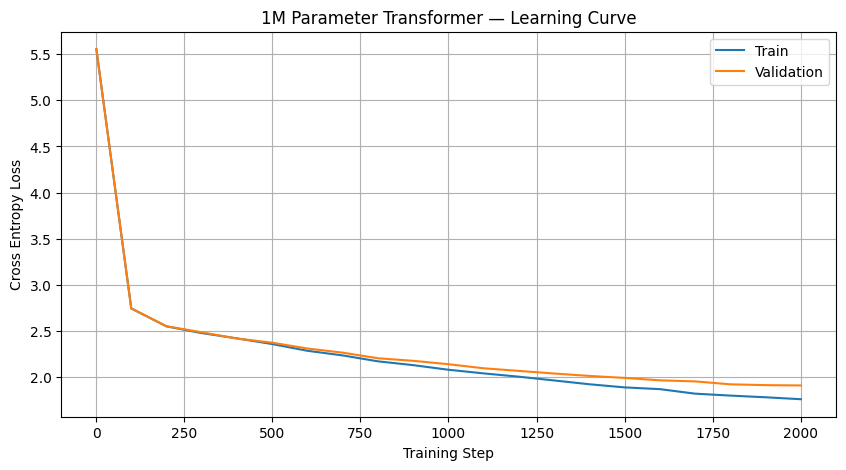


FINAL EVALUATION
Train loss: 1.7596
Validation loss: 1.9090
Validation perplexity: 6.75

GENERATED TEXT

ROMEO: you upon,
What, I bespuakins did ploly thice homp fair our him our sweell
But for this to meading to the take my and weare
to greap's them sonteer ther from the
What know my your Ent fom thy treas an the hearr livong
This not nemer and shee honoul one she soneeds,
The spet the for true thir them had tall be tranch,
Hompare aid that' sir.

CLAURINA:
I shee be his the to sonte battid gent,
That of Ise bone you him wand way moth.

Thist Clancrace:
The loves you wall: that fay: theree thou great to 

TEMPERATURE COMPARISON

--- Temperature = 0.3 ---
ROMEO: that then the that he son,
The how the with hath so like the here and the poores,
And the the the hone the the stay the the hearth,
The heart on the to sond the sond the seall and
This he seall the sh

--- Temperature = 0.7 ---
ROMEO: when, if were hear wenth
spon eard me his impent to me worth thee; his and
Depson hear have h

In [2]:
# ============================================================
# FIRST REAL LANGUAGE MODEL TRAINING EXPERIMENT
# FROM RAW TEXT → TRAINED MODEL → GENERATED TEXT
# ============================================================

# ------------------------------------------------------------
# 0. IMPORTS
# ------------------------------------------------------------

import math
import time
import requests
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. DEVICE
# ------------------------------------------------------------

device = "cuda" if torch.cuda.is_available() else "cpu"

print("=" * 75)
print("DEVICE")
print("=" * 75)

print("Device:", device)

if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


# ============================================================
# 2. CONFIGURATION
# ============================================================

VOCAB_SIZE = 256

CONTEXT_LENGTH = 128

D = 128
H = 4
F_DIM = 512
L = 5

BATCH_SIZE = 32

TRAIN_STEPS = 2000

LEARNING_RATE = 3e-4

WEIGHT_DECAY = 0.1

LOG_EVERY = 100

EVAL_BATCHES = 20

SEED = 42

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


print()
print("=" * 75)
print("MODEL CONFIGURATION")
print("=" * 75)

print(f"Vocabulary       V = {VOCAB_SIZE}")
print(f"Context length   T = {CONTEXT_LENGTH}")
print(f"Model dimension  D = {D}")
print(f"Attention heads  H = {H}")
print(f"Head dimension     = {D // H}")
print(f"FFN dimension    F = {F_DIM}")
print(f"Layers           L = {L}")
print(f"Batch size         = {BATCH_SIZE}")
print(f"Training steps     = {TRAIN_STEPS}")


# ============================================================
# 3. LOAD REAL TEXT
# ============================================================

url = (
    "https://raw.githubusercontent.com/"
    "karpathy/char-rnn/master/data/"
    "tinyshakespeare/input.txt"
)

text = requests.get(url).text

print()
print("=" * 75)
print("DATASET")
print("=" * 75)

print("Characters:", len(text))

print()
print("Sample:")
print(text[:300])


# ============================================================
# 4. BYTE TOKENIZER
# ============================================================

encoded = text.encode("utf-8")

data = torch.tensor(
    list(encoded),
    dtype=torch.long
)

print()
print("Total byte tokens:", len(data))

print(
    "Minimum token:",
    data.min().item()
)

print(
    "Maximum token:",
    data.max().item()
)


# ============================================================
# 5. ENCODE / DECODE
# ============================================================

def encode(text):

    return torch.tensor(
        list(text.encode("utf-8")),
        dtype=torch.long
    )


def decode(tokens):

    if isinstance(tokens, torch.Tensor):
        tokens = tokens.tolist()

    return bytes(tokens).decode(
        "utf-8",
        errors="replace"
    )


# ============================================================
# 6. TRAIN / VALIDATION SPLIT
# ============================================================

split = int(
    len(data) * 0.90
)

train_data = data[:split]

val_data = data[split:]

print()
print("=" * 75)
print("DATA SPLIT")
print("=" * 75)

print("Train tokens:", len(train_data))
print("Val tokens  :", len(val_data))


# ============================================================
# 7. BATCH SAMPLER
# ============================================================

def get_batch(
    source,
    batch_size=BATCH_SIZE,
    context_length=CONTEXT_LENGTH
):

    starts = torch.randint(
        0,
        len(source) - context_length - 1,
        (batch_size,)
    )

    x = torch.stack([
        source[
            i:i + context_length
        ]
        for i in starts
    ])

    y = torch.stack([
        source[
            i + 1:i + context_length + 1
        ]
        for i in starts
    ])

    return (
        x.to(device),
        y.to(device)
    )


# ============================================================
# 8. RMS NORM
# ============================================================

class RMSNorm(nn.Module):

    def __init__(
        self,
        dim,
        eps=1e-6
    ):

        super().__init__()

        self.eps = eps

        self.weight = nn.Parameter(
            torch.ones(dim)
        )

    def forward(self, x):

        rms = torch.sqrt(
            x.pow(2).mean(
                dim=-1,
                keepdim=True
            )
            + self.eps
        )

        return (
            x / rms
        ) * self.weight


# ============================================================
# 9. SELF ATTENTION
# ============================================================

class SelfAttention(nn.Module):

    def __init__(
        self,
        D,
        H,
        max_seq_len
    ):

        super().__init__()

        assert D % H == 0

        self.D = D
        self.H = H
        self.head_dim = D // H

        # ----------------------------------------------------
        # Q K V
        # ----------------------------------------------------

        self.q_proj = nn.Linear(
            D,
            D,
            bias=False
        )

        self.k_proj = nn.Linear(
            D,
            D,
            bias=False
        )

        self.v_proj = nn.Linear(
            D,
            D,
            bias=False
        )

        # ----------------------------------------------------
        # OUTPUT PROJECTION
        # ----------------------------------------------------

        self.o_proj = nn.Linear(
            D,
            D,
            bias=False
        )

        # ----------------------------------------------------
        # CAUSAL MASK
        # ----------------------------------------------------

        mask = torch.tril(
            torch.ones(
                max_seq_len,
                max_seq_len
            )
        )

        self.register_buffer(
            "mask",
            mask
        )

    def forward(self, x):

        B, T, D = x.shape

        # ----------------------------------------------------
        # PROJECT
        # ----------------------------------------------------

        q = self.q_proj(x)

        k = self.k_proj(x)

        v = self.v_proj(x)

        # ----------------------------------------------------
        # SPLIT HEADS
        # ----------------------------------------------------

        q = q.view(
            B,
            T,
            self.H,
            self.head_dim
        )

        k = k.view(
            B,
            T,
            self.H,
            self.head_dim
        )

        v = v.view(
            B,
            T,
            self.H,
            self.head_dim
        )

        # [B,T,H,Hd]
        #
        # →
        #
        # [B,H,T,Hd]

        q = q.transpose(1, 2)

        k = k.transpose(1, 2)

        v = v.transpose(1, 2)

        # ----------------------------------------------------
        # ATTENTION SCORES
        # ----------------------------------------------------

        scores = (
            q @ k.transpose(-2, -1)
        ) / math.sqrt(
            self.head_dim
        )

        # [B,H,T,T]

        # ----------------------------------------------------
        # CAUSAL MASK
        # ----------------------------------------------------

        causal = (
            self.mask[:T, :T]
            .bool()
        )

        scores = scores.masked_fill(
            ~causal,
            float("-inf")
        )

        # ----------------------------------------------------
        # SOFTMAX
        # ----------------------------------------------------

        weights = F.softmax(
            scores,
            dim=-1
        )

        # ----------------------------------------------------
        # WEIGHTED VALUES
        # ----------------------------------------------------

        out = weights @ v

        # [B,H,T,Hd]
        #
        # →
        #
        # [B,T,H,Hd]

        out = out.transpose(
            1,
            2
        )

        # ----------------------------------------------------
        # MERGE HEADS
        # ----------------------------------------------------

        out = out.contiguous().view(
            B,
            T,
            D
        )

        # ----------------------------------------------------
        # OUTPUT PROJECTION
        # ----------------------------------------------------

        out = self.o_proj(out)

        return out


# ============================================================
# 10. FEED-FORWARD NETWORK
# ============================================================

class FeedForward(nn.Module):

    def __init__(
        self,
        D,
        F_DIM
    ):

        super().__init__()

        self.fc1 = nn.Linear(
            D,
            F_DIM,
            bias=False
        )

        self.fc2 = nn.Linear(
            F_DIM,
            D,
            bias=False
        )

    def forward(self, x):

        x = self.fc1(x)

        x = F.gelu(x)

        x = self.fc2(x)

        return x


# ============================================================
# 11. TRANSFORMER BLOCK
# ============================================================

class TransformerBlock(nn.Module):

    def __init__(
        self,
        D,
        H,
        F_DIM,
        max_seq_len
    ):

        super().__init__()

        self.norm1 = RMSNorm(D)

        self.attention = SelfAttention(
            D,
            H,
            max_seq_len
        )

        self.norm2 = RMSNorm(D)

        self.ffn = FeedForward(
            D,
            F_DIM
        )

    def forward(self, x):

        # ----------------------------------------------------
        # ATTENTION + RESIDUAL
        # ----------------------------------------------------

        x = x + self.attention(
            self.norm1(x)
        )

        # ----------------------------------------------------
        # FFN + RESIDUAL
        # ----------------------------------------------------

        x = x + self.ffn(
            self.norm2(x)
        )

        return x


# ============================================================
# 12. LANGUAGE MODEL
# ============================================================

class TinyLanguageModel(nn.Module):

    def __init__(
        self,
        vocab_size,
        max_seq_len,
        D,
        H,
        F_DIM,
        L
    ):

        super().__init__()

        # ----------------------------------------------------
        # TOKEN EMBEDDING
        # ----------------------------------------------------

        self.token_embedding = nn.Embedding(
            vocab_size,
            D
        )

        # ----------------------------------------------------
        # POSITION EMBEDDING
        # ----------------------------------------------------

        self.position_embedding = nn.Embedding(
            max_seq_len,
            D
        )

        # ----------------------------------------------------
        # TRANSFORMER STACK
        # ----------------------------------------------------

        self.blocks = nn.ModuleList([
            TransformerBlock(
                D,
                H,
                F_DIM,
                max_seq_len
            )
            for _ in range(L)
        ])

        # ----------------------------------------------------
        # FINAL NORMALIZATION
        # ----------------------------------------------------

        self.final_norm = RMSNorm(D)

        # ----------------------------------------------------
        # LANGUAGE MODEL HEAD
        # ----------------------------------------------------

        self.lm_head = nn.Linear(
            D,
            vocab_size,
            bias=False
        )

    def forward(self, tokens):

        B, T = tokens.shape

        assert T <= CONTEXT_LENGTH

        # ----------------------------------------------------
        # TOKEN EMBEDDING
        # ----------------------------------------------------

        x = self.token_embedding(
            tokens
        )

        # ----------------------------------------------------
        # POSITION EMBEDDING
        # ----------------------------------------------------

        positions = torch.arange(
            T,
            device=tokens.device
        )

        x = x + self.position_embedding(
            positions
        )

        # ----------------------------------------------------
        # TRANSFORMER
        # ----------------------------------------------------

        for block in self.blocks:

            x = block(x)

        # ----------------------------------------------------
        # FINAL NORM
        # ----------------------------------------------------

        x = self.final_norm(x)

        # ----------------------------------------------------
        # VOCABULARY LOGITS
        # ----------------------------------------------------

        logits = self.lm_head(x)

        return logits


# ============================================================
# 13. CREATE MODEL
# ============================================================

model = TinyLanguageModel(
    VOCAB_SIZE,
    CONTEXT_LENGTH,
    D,
    H,
    F_DIM,
    L
).to(device)


# ============================================================
# 14. PARAMETER COUNT
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

print()
print("=" * 75)
print("MODEL")
print("=" * 75)

print(
    f"Total parameters: {total_params:,}"
)

print(
    f"Total parameters: {total_params / 1e6:.3f}M"
)


# ============================================================
# 15. PARAMETER BREAKDOWN
# ============================================================

print()
print("=" * 75)
print("PARAMETER BREAKDOWN")
print("=" * 75)

groups = {}

for name, param in model.named_parameters():

    if name.startswith(
        "token_embedding"
    ):
        group = "Token embedding"

    elif name.startswith(
        "position_embedding"
    ):
        group = "Position embedding"

    elif name.startswith(
        "blocks"
    ):
        group = "Transformer blocks"

    elif name.startswith(
        "final_norm"
    ):
        group = "Final norm"

    elif name.startswith(
        "lm_head"
    ):
        group = "LM head"

    else:
        group = "Other"

    groups[group] = (
        groups.get(group, 0)
        + param.numel()
    )

for name, count in groups.items():

    print(
        f"{name:<25}"
        f"{count:>12,}"
        f"   {count/total_params*100:6.2f}%"
    )


# ============================================================
# 16. OPTIMIZER
# ============================================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)


# ============================================================
# 17. EVALUATION FUNCTION
# ============================================================

@torch.no_grad()
def estimate_loss():

    model.eval()

    train_losses = []

    val_losses = []

    for _ in range(EVAL_BATCHES):

        x, y = get_batch(
            train_data
        )

        logits = model(x)

        loss = F.cross_entropy(
            logits.reshape(
                -1,
                VOCAB_SIZE
            ),
            y.reshape(-1)
        )

        train_losses.append(
            loss.item()
        )

    for _ in range(EVAL_BATCHES):

        x, y = get_batch(
            val_data
        )

        logits = model(x)

        loss = F.cross_entropy(
            logits.reshape(
                -1,
                VOCAB_SIZE
            ),
            y.reshape(-1)
        )

        val_losses.append(
            loss.item()
        )

    model.train()

    return (
        sum(train_losses) / len(train_losses),
        sum(val_losses) / len(val_losses)
    )


# ============================================================
# 18. INITIAL LOSS
# ============================================================

initial_train_loss, initial_val_loss = (
    estimate_loss()
)

print()
print("=" * 75)
print("INITIAL LOSS")
print("=" * 75)

print(
    f"Train loss: {initial_train_loss:.4f}"
)

print(
    f"Val loss:   {initial_val_loss:.4f}"
)

print(
    f"Initial perplexity: "
    f"{math.exp(initial_val_loss):.2f}"
)


# ============================================================
# 19. TRAIN
# ============================================================

train_losses = []

val_losses = []

steps = []

print()
print("=" * 75)
print("TRAINING")
print("=" * 75)

start_time = time.time()

model.train()

for step in range(
    1,
    TRAIN_STEPS + 1
):

    # --------------------------------------------------------
    # GET BATCH
    # --------------------------------------------------------

    x, y = get_batch(
        train_data
    )

    # --------------------------------------------------------
    # FORWARD
    # --------------------------------------------------------

    logits = model(x)

    # --------------------------------------------------------
    # LOSS
    # --------------------------------------------------------

    loss = F.cross_entropy(
        logits.reshape(
            -1,
            VOCAB_SIZE
        ),
        y.reshape(-1)
    )

    # --------------------------------------------------------
    # BACKWARD
    # --------------------------------------------------------

    optimizer.zero_grad(
        set_to_none=True
    )

    loss.backward()

    # --------------------------------------------------------
    # GRADIENT CLIPPING
    # --------------------------------------------------------

    torch.nn.utils.clip_grad_norm_(
        model.parameters(),
        1.0
    )

    # --------------------------------------------------------
    # UPDATE
    # --------------------------------------------------------

    optimizer.step()

    # --------------------------------------------------------
    # LOG
    # --------------------------------------------------------

    if (
        step == 1
        or step % LOG_EVERY == 0
    ):

        train_loss, val_loss = (
            estimate_loss()
        )

        train_losses.append(
            train_loss
        )

        val_losses.append(
            val_loss
        )

        steps.append(step)

        elapsed = (
            time.time()
            - start_time
        )

        print(
            f"step {step:5d} | "
            f"train {train_loss:.4f} | "
            f"val {val_loss:.4f} | "
            f"ppl {math.exp(val_loss):7.2f} | "
            f"time {elapsed:6.1f}s"
        )


# ============================================================
# 20. LOSS CURVE
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    steps,
    train_losses,
    label="Train"
)

plt.plot(
    steps,
    val_losses,
    label="Validation"
)

plt.xlabel(
    "Training Step"
)

plt.ylabel(
    "Cross Entropy Loss"
)

plt.title(
    "1M Parameter Transformer — Learning Curve"
)

plt.legend()

plt.grid()

plt.show()


# ============================================================
# 21. PERPLEXITY
# ============================================================

final_train_loss = train_losses[-1]

final_val_loss = val_losses[-1]

print()
print("=" * 75)
print("FINAL EVALUATION")
print("=" * 75)

print(
    f"Train loss: {final_train_loss:.4f}"
)

print(
    f"Validation loss: {final_val_loss:.4f}"
)

print(
    f"Validation perplexity: "
    f"{math.exp(final_val_loss):.2f}"
)


# ============================================================
# 22. TEXT GENERATION
# ============================================================

@torch.no_grad()
def generate(
    model,
    prompt,
    max_new_tokens=300,
    temperature=0.8,
    top_k=50
):

    model.eval()

    tokens = encode(
        prompt
    ).unsqueeze(0).to(device)

    for _ in range(
        max_new_tokens
    ):

        # ----------------------------------------------------
        # KEEP ONLY CONTEXT WINDOW
        # ----------------------------------------------------

        context = tokens[
            :,
            -CONTEXT_LENGTH:
        ]

        # ----------------------------------------------------
        # FORWARD
        # ----------------------------------------------------

        logits = model(
            context
        )

        # Last position

        logits = logits[
            :, -1, :
        ]

        # ----------------------------------------------------
        # TEMPERATURE
        # ----------------------------------------------------

        logits = (
            logits / temperature
        )

        # ----------------------------------------------------
        # TOP-K
        # ----------------------------------------------------

        if top_k is not None:

            values, indices = torch.topk(
                logits,
                min(top_k, logits.size(-1))
            )

            filtered = torch.full_like(
                logits,
                float("-inf")
            )

            filtered.scatter_(
                1,
                indices,
                values
            )

            logits = filtered

        # ----------------------------------------------------
        # PROBABILITIES
        # ----------------------------------------------------

        probs = F.softmax(
            logits,
            dim=-1
        )

        # ----------------------------------------------------
        # SAMPLE
        # ----------------------------------------------------

        next_token = torch.multinomial(
            probs,
            num_samples=1
        )

        tokens = torch.cat(
            [
                tokens,
                next_token
            ],
            dim=1
        )

    model.train()

    return decode(
        tokens[0]
    )


# ============================================================
# 23. GENERATE TEXT
# ============================================================

print()
print("=" * 75)
print("GENERATED TEXT")
print("=" * 75)

prompt = "ROMEO: "

generated = generate(
    model,
    prompt,
    max_new_tokens=500,
    temperature=0.8,
    top_k=50
)

print()
print(generated)


# ============================================================
# 24. TRY DIFFERENT TEMPERATURES
# ============================================================

print()
print("=" * 75)
print("TEMPERATURE COMPARISON")
print("=" * 75)

for temperature in [
    0.3,
    0.7,
    1.0
]:

    print()
    print(
        f"--- Temperature = {temperature} ---"
    )

    result = generate(
        model,
        "ROMEO: ",
        max_new_tokens=200,
        temperature=temperature,
        top_k=50
    )

    print(result)


# ============================================================
# 25. FINAL LESSON
# ============================================================

print()
print("=" * 75)
print("WHAT JUST HAPPENED?")
print("=" * 75)

print(
"""
RAW TEXT
   ↓
BYTE TOKENIZER
   ↓
TOKEN IDs
   ↓
TOKEN EMBEDDINGS
   ↓
POSITION EMBEDDINGS
   ↓
5 TRANSFORMER BLOCKS
   ↓
FINAL RMS NORM
   ↓
LM HEAD
   ↓
LOGITS
   ↓
CROSS ENTROPY
   ↓
BACKPROPAGATION
   ↓
ADAMW
   ↓
UPDATED PARAMETERS
   ↓
REPEAT
   ↓
MODEL LEARNS PATTERNS
"""
)